<a href="https://colab.research.google.com/github/techminds3009/genai_roadmap/blob/initial_branch/loss_functiondemo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

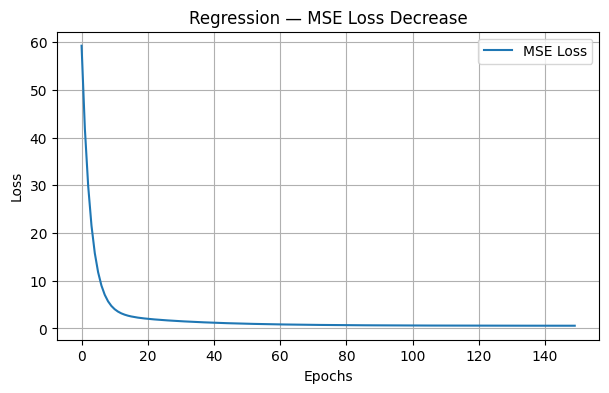

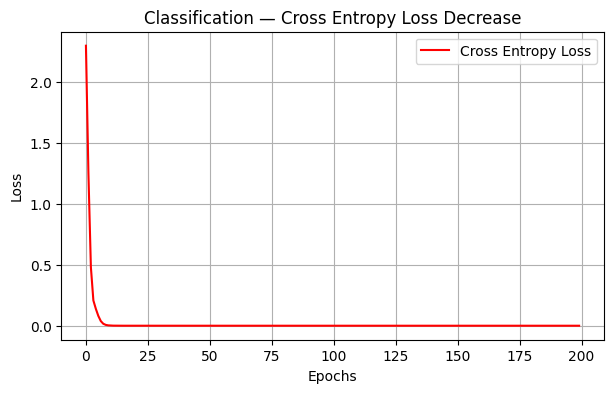

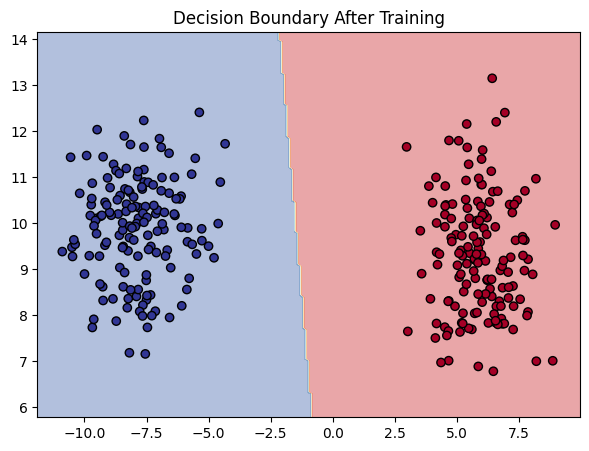

Demo Completed ✔️


In [ ]:
# ------------------------------------------------------------
# LOSS FUNCTION VISUALIZATION DEMO
# MSE (Regression) + Cross Entropy (Classification)
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# ------------------------------------------------------------
# PART 1 — REGRESSION + MSE LOSS VISUALIZATION
# ------------------------------------------------------------

# Generate simple regression data: y = 3x + 2
X = torch.linspace(-5, 5, 100).reshape(-1, 1)
y = 3 * X + 2 + 0.8 * torch.randn(X.shape)   # add noise

# A simple linear model
model_reg = nn.Linear(1, 1)

loss_fn = nn.MSELoss()
optimizer = optim.SGD(model_reg.parameters(), lr=0.01)

mse_losses = []

# Train regression model
for epoch in range(150):
    optimizer.zero_grad()
    y_pred = model_reg(X)
    loss = loss_fn(y_pred, y)
    loss.backward()
    optimizer.step()
    mse_losses.append(loss.item())

# Plot regression loss curve
plt.figure(figsize=(7, 4))
plt.plot(mse_losses, label="MSE Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Regression — MSE Loss Decrease")
plt.grid(True)
plt.legend()
plt.show()

# ------------------------------------------------------------
# PART 2 — CLASSIFICATION + CROSS ENTROPY VISUALIZATION
# ------------------------------------------------------------

# Simple classification dataset (2 classes)
from sklearn.datasets import make_blobs

Xc, yc = make_blobs(n_samples=300, centers=2, n_features=2, cluster_std=1.2)
Xc = torch.tensor(Xc, dtype=torch.float32)
yc = torch.tensor(yc, dtype=torch.long)

model_clf = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 2),
)

loss_fn_ce = nn.CrossEntropyLoss()
optimizer_clf = optim.Adam(model_clf.parameters(), lr=0.02)

ce_losses = []

# Training loop
for epoch in range(200):
    optimizer_clf.zero_grad()
    logits = model_clf(Xc)
    loss = loss_fn_ce(logits, yc)
    loss.backward()
    optimizer_clf.step()
    ce_losses.append(loss.item())

# Plot classification loss curve
plt.figure(figsize=(7, 4))
plt.plot(ce_losses, color="red", label="Cross Entropy Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Classification — Cross Entropy Loss Decrease")
plt.grid(True)
plt.legend()
plt.show()

# ------------------------------------------------------------
# PART 3 — VISUALIZE DECISION BOUNDARY (classification)
# ------------------------------------------------------------

def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    pred = model(grid).detach().numpy().argmax(axis=1)
    pred = pred.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, pred, alpha=0.4, cmap="RdYlBu")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdYlBu", edgecolor="black")
    plt.title("Decision Boundary After Training")
    plt.show()

plot_decision_boundary(model_clf, Xc, yc)

print("Demo Completed ✔️")
